In [1]:
# HEART DISEASE SEVERITY PREDICTION — UCI Dataset
# Multiclass Classification using Scikit-learn & XGBoost

!pip install ucimlrepo xgboost --quiet
!pip install imbalanced-learn --quiet



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\arnab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\arnab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from xgboost import XGBClassifier
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# ── 2. LOAD DATASET ──────────────────────────────────────────
heart = fetch_ucirepo(id=45)
X = heart.data.features
y = heart.data.targets

print("Dataset shape:", X.shape)
print("Target distribution:\n", y.value_counts())
X.head()


Dataset shape: (303, 13)
Target distribution:
 num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [3]:
df = X.copy()
df['target'] = y.values.ravel()

# Drop rows with too many nulls, fill remaining with median
df.dropna(thresh=len(df.columns) - 2, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nClass distribution:\n", df['target'].value_counts().sort_index())

# Features & target
X_clean = df.drop('target', axis=1)
y_clean = df['target'].astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain size: {X_train_sc.shape}, Test size: {X_test_sc.shape}")



Missing values after cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Class distribution:
 target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Train size: (242, 13), Test size: (61, 13)


In [4]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)

print("\n── Random Forest ──")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, zero_division=0))


── Random Forest ──
Accuracy: 0.5082
              precision    recall  f1-score   support

           0       0.76      0.94      0.84        33
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.51        61
   macro avg       0.15      0.19      0.17        61
weighted avg       0.41      0.51      0.45        61



In [5]:
n_classes = len(np.unique(y_clean))

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train_sc, y_train)
xgb_pred = xgb.predict(X_test_sc)

print("\n── XGBoost ──")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred, zero_division=0))



── XGBoost ──
Accuracy: 0.5410
              precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.08      0.09      0.08        11
           2       0.17      0.14      0.15         7
           3       0.17      0.14      0.15         7
           4       0.00      0.00      0.00         3

    accuracy                           0.54        61
   macro avg       0.25      0.26      0.25        61
weighted avg       0.50      0.54      0.52        61



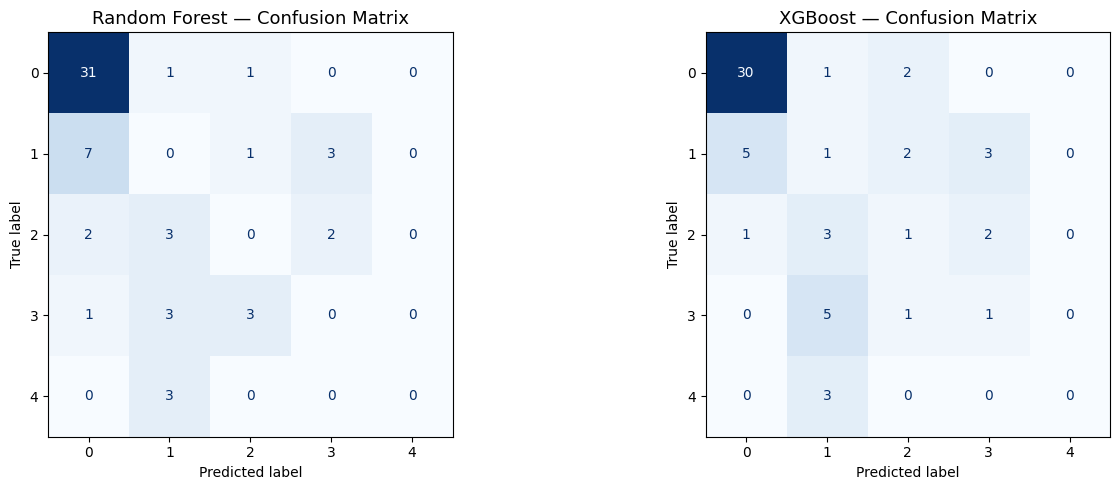

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                             [rf_pred, xgb_pred],
                             ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=sorted(y_clean.unique()))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


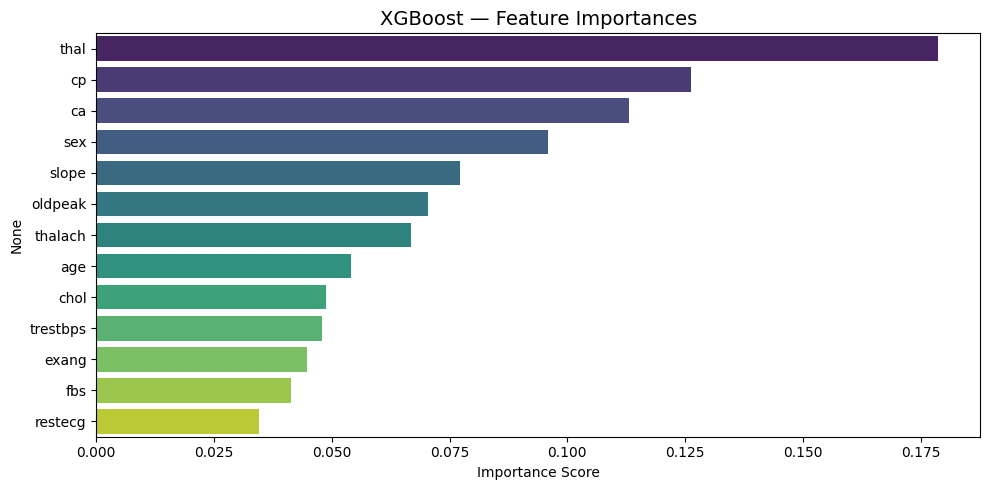

In [7]:
importances = pd.Series(xgb.feature_importances_, index=X_clean.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_sorted.values, y=importances_sorted.index, palette='viridis')
plt.title('XGBoost — Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


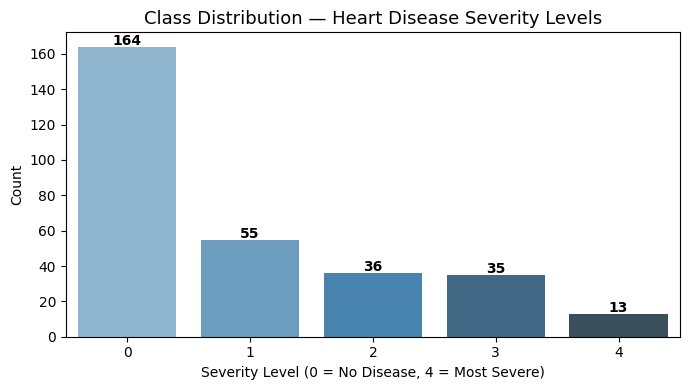

In [8]:
plt.figure(figsize=(7, 4))
class_counts = y_clean.value_counts().sort_index()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='Blues_d')
plt.title('Class Distribution — Heart Disease Severity Levels', fontsize=13)
plt.xlabel('Severity Level (0 = No Disease, 4 = Most Severe)')
plt.ylabel('Count')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()


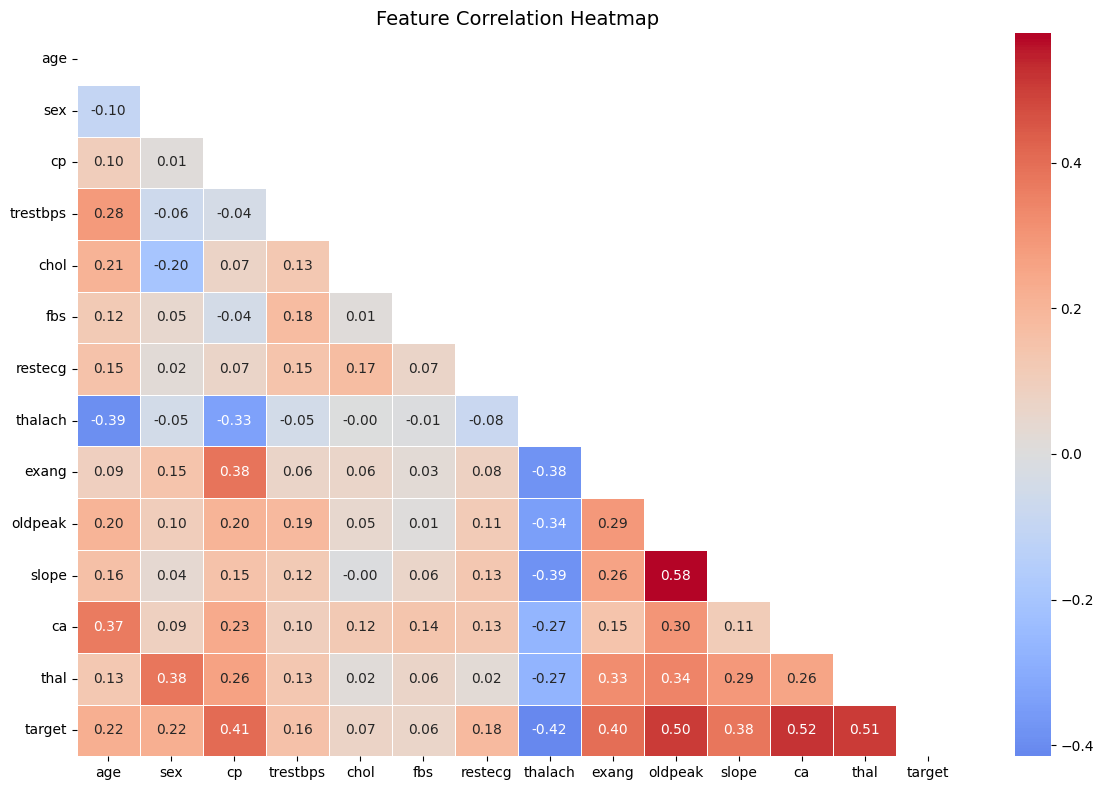

In [9]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

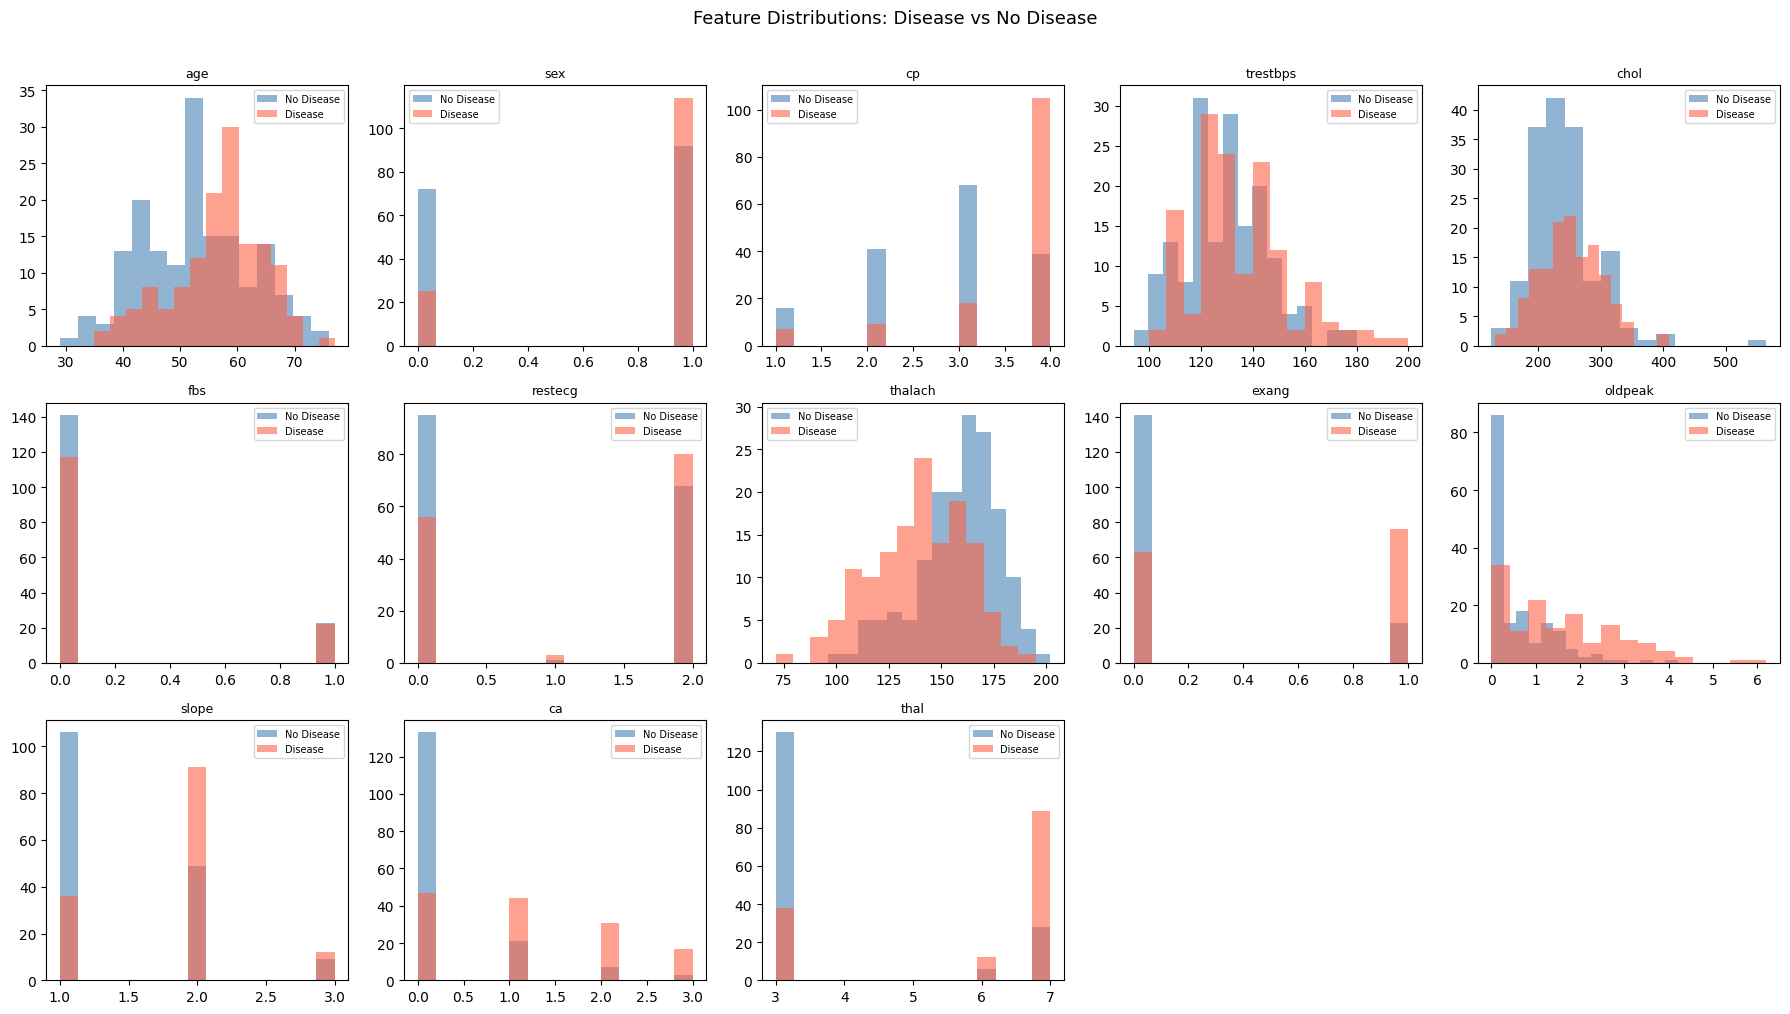

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(X_clean.columns):
    axes[i].hist(df[df['target'] == 0][col], alpha=0.6, label='No Disease', color='steelblue', bins=15)
    axes[i].hist(df[df['target'] > 0][col],  alpha=0.6, label='Disease',    color='tomato',    bins=15)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
# hide extra subplots if any
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions: Disease vs No Disease', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [11]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", Counter(y_train))
sm = SMOTE(random_state=42, k_neighbors=1)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)
print("After SMOTE: ", Counter(y_train_res))

Before SMOTE: Counter({0: 131, 1: 44, 2: 29, 3: 28, 4: 10})
After SMOTE:  Counter({3: 131, 0: 131, 1: 131, 2: 131, 4: 131})


In [13]:
lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr.fit(X_train_res, y_train_res)
lr_pred = lr.predict(X_test_sc)

print("\n── Logistic Regression (Baseline) ──")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, zero_division=0))



── Logistic Regression (Baseline) ──
Accuracy: 0.4918
              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.27      0.36      0.31        11
           2       0.33      0.14      0.20         7
           3       0.29      0.29      0.29         7
           4       0.11      0.33      0.17         3

    accuracy                           0.49        61
   macro avg       0.36      0.36      0.34        61
weighted avg       0.57      0.49      0.52        61



In [14]:
rf.fit(X_train_res, y_train_res)
rf_pred = rf.predict(X_test_sc)

xgb.fit(X_train_res, y_train_res)
xgb_pred = xgb.predict(X_test_sc)

print("\n── Random Forest (after SMOTE) ──")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

print("\n── XGBoost (after SMOTE) ──")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")



── Random Forest (after SMOTE) ──
Accuracy: 0.5410

── XGBoost (after SMOTE) ──
Accuracy: 0.4426


In [15]:
from sklearn.model_selection import cross_val_score

print("\n── 5-Fold Cross Validation ──")
for name, model in [('Logistic Regression', lr),
                     ('Random Forest',       rf),
                     ('XGBoost',             xgb)]:
    scores = cross_val_score(model, scaler.transform(X_clean),
                              y_clean, cv=5, scoring='accuracy')
    print(f"{name:22s} → Mean: {scores.mean():.4f}  Std: {scores.std():.4f}  All: {np.round(scores, 4)}")



── 5-Fold Cross Validation ──
Logistic Regression    → Mean: 0.5974  Std: 0.0639  All: [0.6393 0.6557 0.4754 0.6167 0.6   ]
Random Forest          → Mean: 0.5775  Std: 0.0255  All: [0.6066 0.6066 0.541  0.5667 0.5667]
XGBoost                → Mean: 0.5742  Std: 0.0339  All: [0.5902 0.623  0.5246 0.5833 0.55  ]


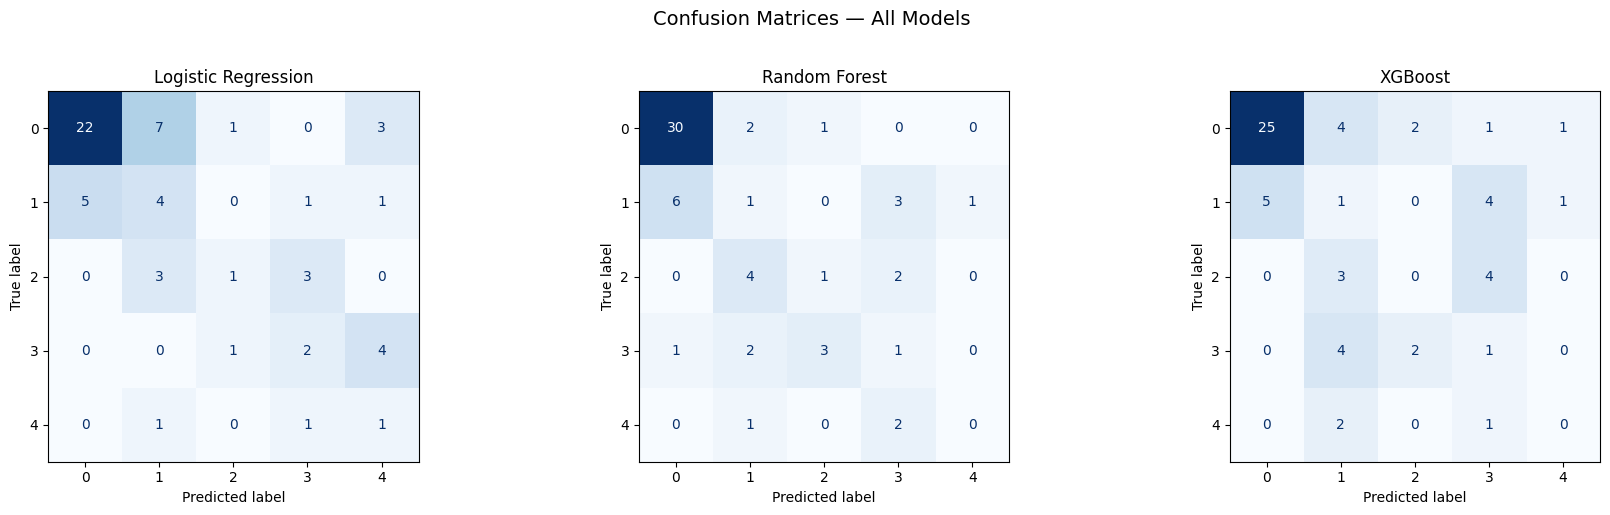

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = sorted(y_clean.unique())

for ax, preds, title in zip(axes,
                             [lr_pred, rf_pred, xgb_pred],
                             ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}', fontsize=12)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150)
plt.show()


In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=sorted(y_clean.unique()))

print("\n── Multiclass ROC-AUC (OvR, weighted) ──")
for name, model in [('Logistic Regression', lr),
                     ('Random Forest',       rf),
                     ('XGBoost',             xgb)]:
    proba = model.predict_proba(X_test_sc)
    auc = roc_auc_score(y_test_bin, proba,
                        multi_class='ovr', average='weighted')
    print(f"{name:22s} → AUC: {auc:.4f}")


── Multiclass ROC-AUC (OvR, weighted) ──
Logistic Regression    → AUC: 0.8027
Random Forest          → AUC: 0.8070
XGBoost                → AUC: 0.7710


In [18]:
lr_acc  = accuracy_score(y_test, lr_pred)
rf_acc  = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

from sklearn.metrics import f1_score
summary = pd.DataFrame({
    'Model':      ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy':   [round(lr_acc,  4), round(rf_acc,  4), round(xgb_acc, 4)],
    'F1 (weighted)': [
        round(f1_score(y_test, lr_pred,  average='weighted', zero_division=0), 4),
        round(f1_score(y_test, rf_pred,  average='weighted', zero_division=0), 4),
        round(f1_score(y_test, xgb_pred, average='weighted', zero_division=0), 4),
    ]
})
print("\n── Final Model Comparison ──")
print(summary.to_string(index=False))

best_idx = summary['Accuracy'].idxmax()
print(f"\n Best Model: {summary.loc[best_idx, 'Model']} "
      f"with Accuracy {summary.loc[best_idx, 'Accuracy']}")


── Final Model Comparison ──
              Model  Accuracy  F1 (weighted)
Logistic Regression    0.4918         0.5161
      Random Forest    0.5410         0.5153
            XGBoost    0.4426         0.4565

 Best Model: Random Forest with Accuracy 0.541


In [19]:
import joblib

best_model = [lr, rf, xgb][best_idx]
joblib.dump(best_model, 'best_heart_disease_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print("\n Best model and scaler saved.")

# Load and verify
loaded_model = joblib.load('best_heart_disease_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
test_pred = loaded_model.predict(loaded_scaler.transform(X_test))
print(f" Loaded model accuracy: {accuracy_score(y_test, test_pred):.4f}")


 Best model and scaler saved.
 Loaded model accuracy: 0.5410
